In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from tsfdata import TsfData

In [4]:
def get_maldi_frame_coordinates(tsf):
    cur = tsf.conn.cursor()
    cur.execute("SELECT Frame, XIndexPos, YIndexPos FROM MaldiFrameInfo ORDER BY Frame")
    rows = cur.fetchall()
    if not rows:
        raise RuntimeError("MaldiFrameInfo table is empty — is this a MALDI dataset?")
    return {int(frame): (int(x), int(y)) for frame, x, y in rows}


def extract_ion_image(d_folder, mz_min, mz_max, normalize=False):
    with TsfData(d_folder) as tsf:
        coord_map = get_maldi_frame_coordinates(tsf)

        xs = [v[0] for v in coord_map.values()]
        ys = [v[1] for v in coord_map.values()]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        width  = x_max - x_min + 1
        height = y_max - y_min + 1
        image  = np.zeros((height, width), dtype=np.float64)

        print(f"Grid size: {width} x {height}  ({len(coord_map)} frames)")

        for frame_id, (x, y) in coord_map.items():
            try:
                index_arr, intensity_arr = tsf.readLineSpectrum(frame_id)
            except Exception as exc:
                print(f"Warning: frame {frame_id} failed ({exc}), skipping.")
                continue

            if len(index_arr) == 0:
                continue

            idx_lo, idx_hi = tsf.mzToIndex(frame_id, [mz_min, mz_max])
            if idx_lo > idx_hi:
                idx_lo, idx_hi = idx_hi, idx_lo

            mask = (index_arr >= idx_lo) & (index_arr <= idx_hi)
            window_intensity = float(np.sum(intensity_arr[mask]))

            if normalize:
                total = float(np.sum(intensity_arr))
                window_intensity = (window_intensity / total) if total > 0 else 0.0

            image[y - y_min, x - x_min] = window_intensity

    return image

In [5]:
D_FOLDER  = r"C:\Users\maddi\Documents\ColleyVUApps\QTOFBrain\RatBrainNeg.d"
MZ_MIN    = 885.53
MZ_MAX    = 885.55
NORMALIZE = False   # set True to divide by TIC

image = extract_ion_image(D_FOLDER, MZ_MIN, MZ_MAX, normalize=NORMALIZE)

Grid size: 295 x 156  (45927 frames)


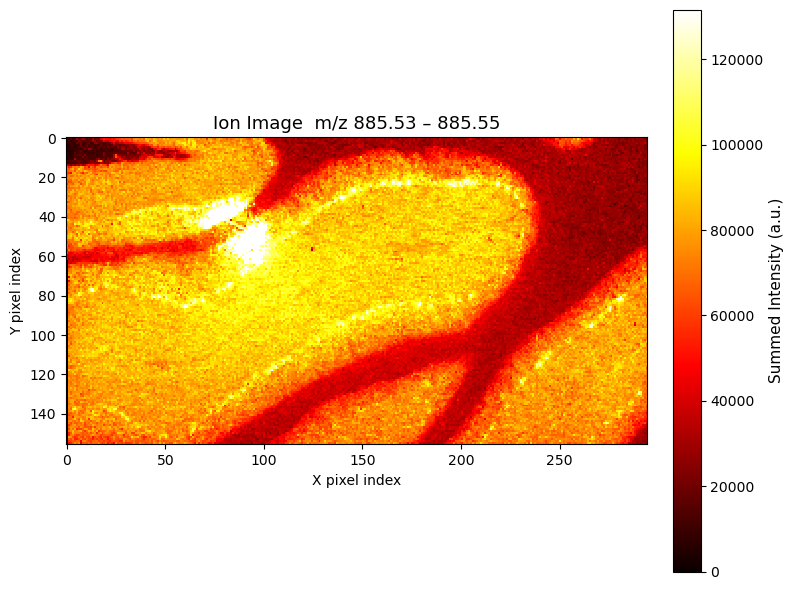

In [6]:
%matplotlib inline

nonzero = image[image > 0]
vmax = float(np.percentile(nonzero, 99)) if nonzero.size > 0 else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(image, cmap="hot", origin="upper", vmin=0, vmax=vmax,
               interpolation="nearest", aspect="equal")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Summed Intensity (a.u.)", fontsize=11)
ax.set_title(f"Ion Image  m/z {MZ_MIN} – {MZ_MAX}", fontsize=13)
ax.set_xlabel("X pixel index")
ax.set_ylabel("Y pixel index")
plt.tight_layout()
plt.show()

In [7]:
##Commenting out for ease - mec fig.savefig("ion_image.png", dpi=150, bbox_inches="tight")

In [8]:
from tqdm.notebook import tqdm
import math

# ── 1. Load the full spectrum (summed across all frames) to find top peaks ───

print("Building summed spectrum across all frames...")

with TsfData(D_FOLDER) as tsf:
    coord_map = get_maldi_frame_coordinates(tsf)
    
    # Use first frame to get the m/z axis length and calibration
    first_frame = next(iter(coord_map))
    _, sample_intensities = tsf.readLineSpectrum(first_frame)
    
    # Accumulate a summed spectrum: {index -> total intensity}
    summed_indices   = {}
    summed_intensity = {}

    for frame_id in tqdm(coord_map, desc="Summing spectra", unit="frame"):
        try:
            index_arr, intensity_arr = tsf.readLineSpectrum(frame_id)
        except Exception:
            continue
        for idx, inten in zip(index_arr, intensity_arr):
            key = round(float(idx), 2)  # bin to 2 decimal places
            summed_intensity[key] = summed_intensity.get(key, 0.0) + float(inten)
            summed_indices[key]   = float(idx)

# ── 2. Convert index keys to m/z values and find top 10% peaks ──────────────

print("Finding top 10% peaks...")

with TsfData(D_FOLDER) as tsf:
    index_keys = np.array(sorted(summed_intensity.keys()))
    total_inten = np.array([summed_intensity[k] for k in index_keys])

    # Convert detector indices -> m/z using the first frame's calibration
    mz_values = tsf.indexToMz(first_frame, index_keys)

# Intensity threshold for top 10%
threshold = np.percentile(total_inten, 90)
top_mask  = total_inten >= threshold

top_mz     = mz_values[top_mask]
top_inten  = total_inten[top_mask]

# Sort by intensity descending, take top 64 for the 8x8 grid
order      = np.argsort(top_inten)[::-1]
top_mz     = top_mz[order][:64]
top_inten  = top_inten[order][:64]

print(f"  Peaks above 90th percentile : {top_mask.sum()}")
print(f"  Showing top {len(top_mz)} in grid")

# ── 3. Extract an ion image for each selected peak (±0.05 Da window) ─────────

WINDOW_DA = 0.05   # half-width of m/z extraction window in Daltons

peak_images = []

for mz in tqdm(top_mz, desc="Extracting ion images", unit="peak"):
    img = extract_ion_image(D_FOLDER, mz - WINDOW_DA, mz + WINDOW_DA, normalize=False)
    peak_images.append((mz, img))

# ── 4. Plot 8x8 grid ──────────────────────────────────────────────────────────

GRID_COLS = 8
GRID_ROWS = 8
CELL_SIZE = 2.2   # inches per panel

fig, axes = plt.subplots(
    GRID_ROWS, GRID_COLS,
    figsize=(GRID_COLS * CELL_SIZE, GRID_ROWS * CELL_SIZE)
)

for i, ax in enumerate(axes.flat):
    if i < len(peak_images):
        mz, img = peak_images[i]
        nonzero  = img[img > 0]
        vmax     = float(np.percentile(nonzero, 99)) if nonzero.size > 0 else 1.0
        ax.imshow(img, cmap="hot", origin="upper",
                  vmin=0, vmax=vmax, interpolation="nearest", aspect="equal")
        ax.set_title(f"{mz:.3f}", fontsize=7, pad=2)
    else:
        ax.set_visible(False)   # hide unused panels if fewer than 64 peaks

    ax.axis("off")

fig.suptitle("Top 10% Peaks by Summed Intensity — Ion Images (±0.05 Da)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Building summed spectrum across all frames...


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html